# EDA Part 1 (ml.m5.12xlarge)

In [1]:
import os
import pandas as pd
import numpy as np
import functions as func

### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')
str_dirname_output = './output'

str_id = 'uniqueid'
str_datecol = 'applicationdate__app'
str_target = 'target'

list_cols_id = [
    str_id,
    str_datecol,
    str_target,
]

Project: 20231010-gen-xii
Step: 02_eda_pt_1


### Output

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import data

In [4]:
%%time

# import
str_filename = 'df_raw.gzip'
str_uri = f's3://{str_project}/02_pricing_pd/01_data_prep/01_data_collection/output/{str_filename}'
# read from s3
df = pd.read_parquet(str_uri)
# replace
df.replace(['NaN','nan'], np.nan, inplace=True)

# show
df

<timed exec>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


CPU times: user 16.2 s, sys: 30.1 s, total: 46.3 s
Wall time: 7.36 s


,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,RunningNetLoss,bitTarget24Months,target
0,20181103.0,20181103.0,NaN,201810.0,69614.0,2018-11-03,1.0,AU,2018-11-05,6847.0,...,0.327746,0.039116,0,0.910195,auto,0,2018-02-16 12:20:23.657,0.0,0,0
1,20181103.0,20181103.0,NaN,201810.0,69614.0,2018-11-03,1.0,AU,2018-11-05,6847.0,...,0.327746,0.039116,0,0.910195,auto,0,2018-02-16 12:20:23.657,0.0,0,0
2,20181103.0,20181103.0,NaN,201810.0,74719.0,2018-11-03,1.0,AU,2018-11-03,27323.0,...,0.486804,0.111285,0,1.049339,suv,1,2007-02-15 09:05:41.530,0.0,0,0
3,20181103.0,20181103.0,NaN,201810.0,74719.0,2018-11-03,1.0,AU,2018-11-03,27323.0,...,0.486804,0.111285,0,1.049339,suv,1,2007-02-15 09:05:41.530,0.0,0,0
4,20181030.0,20181030.0,NaN,201810.0,65604.0,2018-10-30,1.0,AU,2018-10-30,0.0,...,0.191788,0.071203,0,1.082675,truck,1,2011-05-20 14:53:37.283,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.466477,0.082986,0,0.976902,auto,1,2007-07-09 17:18:19.440,0.0,0,0
186171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.466477,0.082986,0,0.976902,auto,1,2007-07-09 17:18:19.440,0.0,0,0
186172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.352323,0.121456,0,1.149966,auto,0,2013-02-21 14:58:51.357,0.0,0,0
186173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.299975,0.062550,0,0.741723,suv,0,2011-09-20 11:51:00.783,0.0,0,0


### Get data frame information

In [5]:
%%time

# get df info
str_filename = 'dict_df_info.json'
func.get_df_info(
    df=df, 
    str_datecol=str_datecol, 
    str_dirname_output=str_dirname_output, 
    str_filename=str_filename,
)
print('')

{'date_max': '2019-12-31 16:55:22.110000',
 'date_min': '2013-10-01 07:28:54.833000',
 'flt_mean_target': 0.11010071169598495,
 'flt_propna': 0.22340581845253812,
 'int_ncols': 2492,
 'int_nrows': 186175,
 'int_obs_total': 463948100}

CPU times: user 1.24 s, sys: 343 ms, total: 1.59 s
Wall time: 1.36 s


### Get descriptives

In [6]:
%%time

str_filename = 'df_descriptives.csv'
list_cols = [col for col in df.columns if col not in list_cols_id]
df_tmp = func.get_descriptives_by_column(
    df=df[list_cols], 
    str_dirname_output=str_dirname_output, 
    str_filename=str_filename,
)

# show
df_tmp

# save memory
del df_tmp

100%|██████████| 2489/2489 [00:39<00:00, 62.80it/s] 


CPU times: user 40.2 s, sys: 815 ms, total: 41 s
Wall time: 41 s


### Get descriptives by ID columns

In [7]:
%%time

str_filename = 'df_descriptives_id.csv',
df_tmp = func.get_descriptives_by_column(
    df=df[list_cols_id], 
    str_dirname_output=str_dirname_output, 
    str_filename=str_filename,
)

# show
df_tmp

# save memory
del df_tmp

100%|██████████| 3/3 [00:00<00:00, 11.99it/s]

CPU times: user 256 ms, sys: 100 µs, total: 256 ms
Wall time: 255 ms


### Plot proportion ```NaN```

CPU times: user 1.26 s, sys: 100 ms, total: 1.36 s
Wall time: 1.45 s


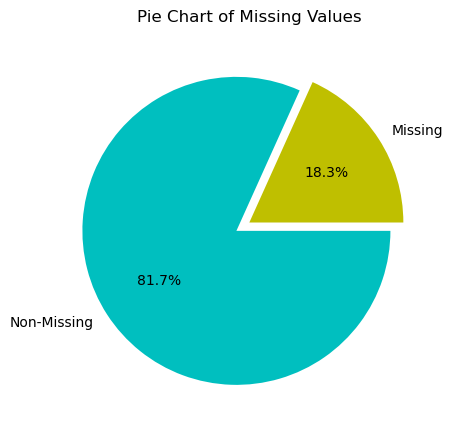

In [8]:
%%time

# plot proportion NaN
try:
    str_filename = 'plt_prop_nan.png',
    func.plot_proportion_nan(
        df=df,
        str_dirname_output=str_dirname_output,
        str_filename=str_filename,
    )
except:
    pass

### Plot data type frequency

100%|██████████| 2492/2492 [00:00<00:00, 20484.16it/s]


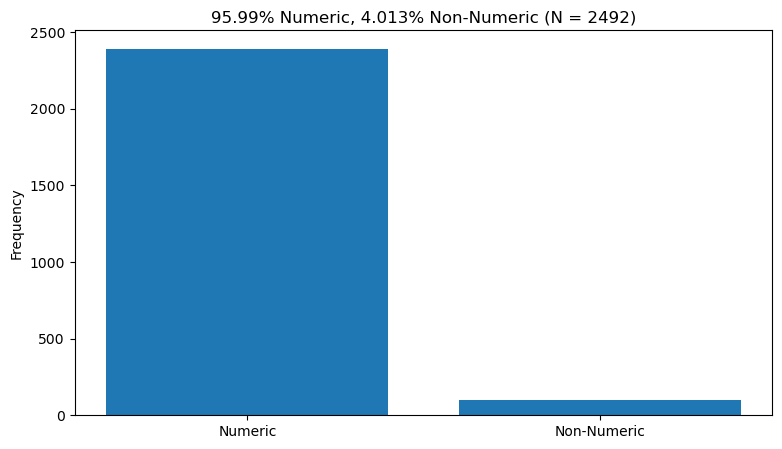

CPU times: user 386 ms, sys: 0 ns, total: 386 ms
Wall time: 385 ms


In [9]:
%%time

# plot data type frequency
str_filename = 'plt_dtype.png'
func.plot_data_type_frequency(
    df=df,
    str_dirname_output=str_dirname_output,
    str_filename=str_filename,
)

### Plot target

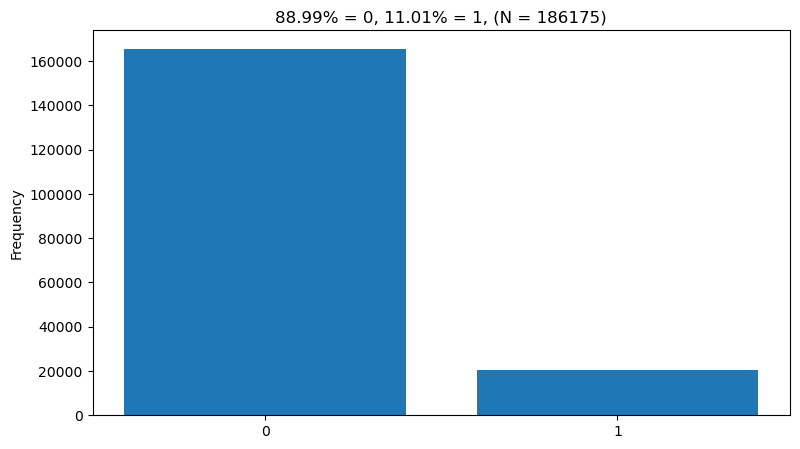

CPU times: user 252 ms, sys: 0 ns, total: 252 ms
Wall time: 250 ms


In [10]:
%%time

# plot target
str_filename = 'plt_target.png'
func.plot_target(
    ser_target=df[str_target],
    str_dirname_output=str_dirname_output,
    str_filename=str_filename,
)

## Write ```README.md``` to local drive

In [11]:
%%writefile README.md

A dictionary of data frame information is available [here](output/dict_df_info.json).

A data frame of descriptive statistics sorted descending by proportion missing by column is available [here](output/df_descriptives.csv).

A data frame of descriptive statistics sorted descending by proportion missing by ID column is available [here](output/df_descriptives_ids.csv).

A plot of percent missing overall in ```df_raw``` is shown below:

<p align="center"><img src="./output/plt_prop_nan.png" width=50% height=50% /></p>

A plot of data type frequency is shown below:
    
<p align="center"><img src="./output/plt_dtype.png" width=50% height=50% /></p>

Plots of the targets are shown below:
    
<p align="center"><img src="./output/plt_target.png" width=50% height=50% /></p>

Overwriting README.md
